### Human in feedback loop

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model='qwen/qwen3.8-27b',
               api_key=api_key)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x74f831ecb380>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x74f831c641a0>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt


In [4]:
class State(TypedDict):
    messages: Annotated[list,add_messages]
    
graph_builder = StateGraph(State)


In [5]:
# Human response
@tool
def human_assistance(quary:str)-> str:
    """Request assistance from a human"""
    human_response = interrupt({'query':quary})
    return human_response['data']


In [6]:
tool = TavilySearch(max_results=2)
tools =[tool,human_assistance]
llm_with_tools = llm.bind_tools(tools)


In [7]:
def chatbot(state:State):
    messages = llm_with_tools.invoke(state["messages"])
    # Becouse we will be interrupting during tool execution
    # we disable parallel tool calling to void repeating any
    # tool invocation when we resume
    
    return {"messages":[messages]}


In [8]:
## Graph builder
graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",tools_condition
)
graph_builder.add_edge("tools",'chatbot')
graph_builder.add_edge(START,"chatbot")


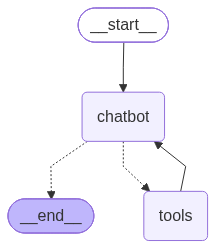

In [9]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [ ]:
user_input = input("Enter the question")
config = {'configurable':{"thread_id":'1'}}

events =graph.stream(
    {'messages':user_input},
    config=config,
    stream_mode='values'
)          

In [11]:
for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()
        
    

================================ Human Message =================================

hello
================================== Ai Message ==================================

Hello! How can I help you today?


In [12]:
user_input = input("Enter the question")
config = {'configurable':{"thread_id":'1'}}

events =graph.stream(
    {'messages':user_input},
    config=config,
    stream_mode='values'
)
for event in events:
    if 'messages' in event:
        event['messages'][-1].pretty_print()
        

================================ Human Message =================================

how to make first million using ai
================================== Ai Message ==================================

Making your first million dollars is a significant financial goal that typically requires a combination of high-value skill, scalable business models, and time. While AI is a powerful tool that can accelerate these processes, it is not a "get rich quick" scheme. It is an enabler that increases leverage, efficiency, and scale.

Here is a realistic, step-by-step framework for using AI to build a business or career path toward your first million:

### 1. Choose a High-Leverage Path
AI works best when applied to problems that have high value or high scale. Pick one of these paths:
*   **Productized Service:** Sell a specific, high-ticket service (e.g., SEO content, video editing, lead generation) where AI handles 70-80% of the production work.
*   **SaaS (Software as a Service):** Build a micro

In [ ]:
user_input=(
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_assistance})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


TypeError: Type is not msgpack serializable: StructuredTool